<a href="https://colab.research.google.com/github/Moulicodes/email-spam-classifier/blob/main/spam_filter.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("mail_data.csv")
df.head()

In [ ]:
print(df['Category'].unique())
print(df['Category'].value_counts())
print(df['Category'].size)
print(df.shape)

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df = df.where(pd.notnull(df), '')
df.head()

In [ ]:
df['Label'] = df['Category'].map({
    'spam': 1,
    'ham': 0
})
df.head()

In [ ]:
from sklearn.model_selection import train_test_split
X = df['Message']
y = df['Label']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 3)

print(f"Total rows in X: {X.shape[0]}")
print(f"Training set size (X_train): {X_train.shape[0]}")
print(f"Testing set size (X_test): {X_test.shape[0]}")

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(min_df = 1, stop_words = 'english', lowercase = True)

X_train_features = tfidf.fit_transform(X_train)
X_test_features = tfidf.transform(X_test)

y_train = y_train.astype('int')
y_test = y_test.astype('int')

print(X_train_features)

print(X_train_features.shape)
print("Text data successfully converted to numeric vectors!")
print(f"Number of unique words (features) found: {X_train_features.shape[1]}")

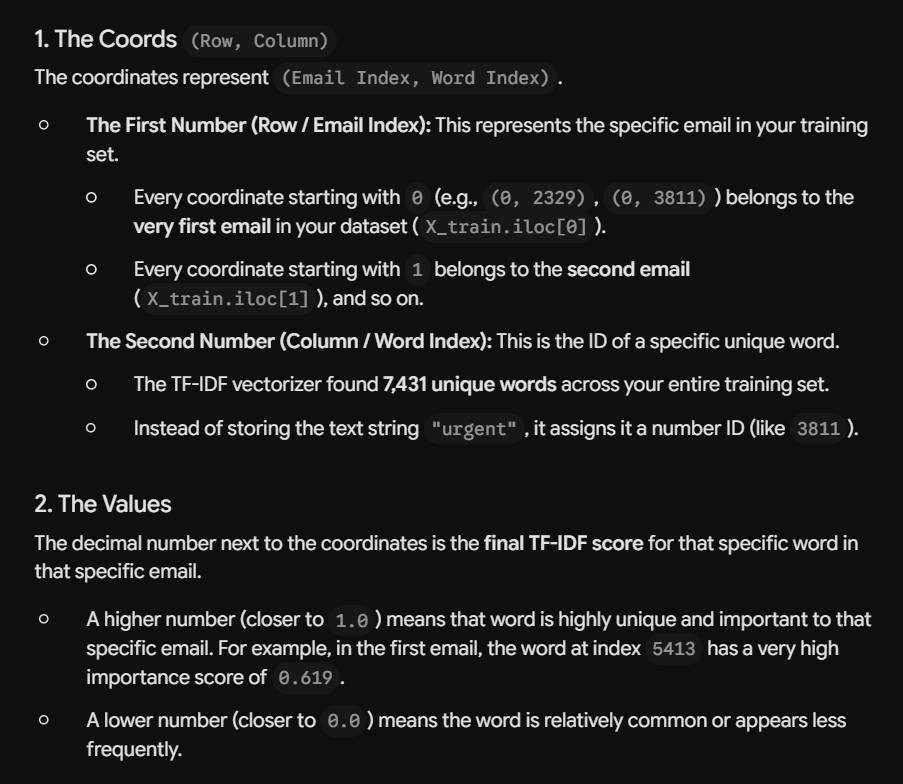

The "Values" column contains L2 normalized TFIDF scores.

What TF-IDF decides: "The word at ID 5413 is highly unique and dominant in email #0, so let's give it a high score of 0.619."

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()

model.fit(X_train_features, y_train)

In [ ]:
from sklearn.metrics import accuracy_score

# 1. Evaluate accuracy on the Training Data
prediction_on_training_data = model.predict(X_train_features)
accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)

# 2. Evaluate accuracy on the Test Data (The true exam)
prediction_on_test_data = model.predict(X_test_features)
accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)

print(f"Accuracy on Training Data: {accuracy_on_training_data * 100:.2f}%")
print(f"Accuracy on Test Data: {accuracy_on_test_data * 100:.2f}%")

In [ ]:
custom_email = ["URGENT! Your mobile number has been awarded a £2000 prize bonus. Call 09066364589 to claim now!"]

custom_email_features = tfidf.transform(custom_email)
custom_email_prediction = model.predict(custom_email_features)

if custom_email_prediction[0] == 1:
  print("WARNING! Spam mail detected")
else:
  print("This mail is classified as Ham")

Cross-Validation - trial 1

In [ ]:
from sklearn.model_selection import cross_val_score

cv_model1 = LogisticRegression()

cv_scores1 = cross_val_score(cv_model1, X_train_features, y_train, cv = 5)

print(f"Accuracy of each fold: {[f'{score * 100: .2f}%' for score in cv_scores1]}")
print(f"Mean validation accuracy of the model: {cv_scores1.mean() * 100: .2f}")

A function to easily handle the cross-validation across various models

In [ ]:
def  validate_model(cv_model, X_train_features, y_train):
  cv_scores = cross_val_score(cv_model, X_train_features, y_train)
  print(f"All scores as percentages: {[f'{score * 100:.2f}%' for score in cv_scores]}")
  print(f"Mean validation accuracy of the model: {cv_scores.mean() * 100: .2f}%")
  print(f"Standard deviation of the validation accuracy of the model: {cv_scores.std() * 100: .2f}%")

1. Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

validate_model(LogisticRegression(), X_train_features, y_train)

2. MultinomialNB

In [ ]:
from sklearn.naive_bayes import MultinomialNB

validate_model(MultinomialNB(), X_train_features, y_train)

3. Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier

validate_model(RandomForestClassifier(n_estimators=100, random_state=42), X_train_features, y_train)

4. Support Vector Machine

In [ ]:
from sklearn.svm import SVC

validate_model(SVC(kernel = 'rbf', C = 1), X_train_features, y_train)

In [ ]:
validate_model(SVC(kernel = 'linear', C = 1), X_train_features, y_train)

5. KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier

validate_model(KNeighborsClassifier(n_neighbors = 3), X_train_features, y_train)

6. Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

validate_model(DecisionTreeClassifier(random_state=42), X_train_features, y_train)

7. GaussianNB

In [ ]:
from sklearn.naive_bayes import GaussianNB

validate_model(GaussianNB(), X_train_features.toarray(), y_train)

Test set predictions

In [ ]:
from sklearn.metrics import precision_score

def evaluate_model(model, X_train_features, y_train, X_test_features, y_test):

  model.fit(X_train_features, y_train)
  prediction_on_training_data = model.predict(X_train_features)
  accuracy_on_training_data = accuracy_score(y_train, prediction_on_training_data)
  precision_on_training_data = precision_score(y_train, prediction_on_training_data)

  prediction_on_test_data = model.predict(X_test_features)
  accuracy_on_test_data = accuracy_score(y_test, prediction_on_test_data)
  precision_on_test_data = precision_score(y_test, prediction_on_test_data)

  print(f"Accuracy on Training Data: {accuracy_on_training_data * 100:.2f}%")
  print(f"Precision on Training Data: {precision_on_training_data * 100:.2f}%")
  print()
  print(f"Accuracy on Test Data: {accuracy_on_test_data * 100:.2f}%")
  print(f"Precision on Test Data: {precision_on_test_data * 100:.2f}%")

1. Linear SVM

In [ ]:
evaluate_model(SVC(kernel = 'linear', C = 1), X_train_features, y_train, X_test_features, y_test)

2. Random Forest

In [ ]:
evaluate_model(RandomForestClassifier(n_estimators=100, random_state=42), X_train_features, y_train, X_test_features, y_test)

3. MultinomialNB

In [ ]:
evaluate_model(MultinomialNB(), X_train_features, y_train, X_test_features, y_test)